In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [3]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[ 9.07832927, -9.96559873],
       [ 9.36480591, -9.06263799],
       [ 6.89428378, -4.20265367],
       ...,
       [ 8.01979839, -3.79096941],
       [ 5.09151502,  6.00756364],
       [ 4.22545148,  5.2603626 ]])

In [5]:
y

array([1, 1, 2, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1, 2, 2, 0, 1, 0, 2, 2, 2, 1,
       1, 0, 0, 1, 1, 1, 2, 2, 1, 0, 1, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 1,
       0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 0, 2, 2, 2, 0, 1, 1, 2, 2, 2, 1, 0,
       2, 2, 1, 1, 0, 1, 1, 2, 1, 0, 1, 1, 2, 2, 2, 2, 0, 2, 2, 1, 0, 0,
       2, 2, 1, 0, 2, 1, 2, 2, 2, 0, 2, 1, 0, 0, 1, 1, 2, 2, 0, 2, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 1, 2, 0, 1,
       1, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 1, 0, 0, 1, 0, 2, 1, 2, 2, 1, 2,
       0, 0, 2, 0, 1, 1, 0, 1, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 2, 0, 1, 0, 1, 0, 0, 0, 0, 1, 2, 0, 1, 2, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 2, 2,
       2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 0, 0, 0, 2, 2, 1, 0, 2, 1, 2,
       0, 0, 1, 2, 1, 1, 0, 2, 0, 2, 2, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0, 2,
       2, 2, 0, 2, 0, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 2, 1, 1, 0, 0, 2,
       0, 1, 2, 2, 1, 0, 1, 0, 1, 0, 1, 1, 2, 0, 2,

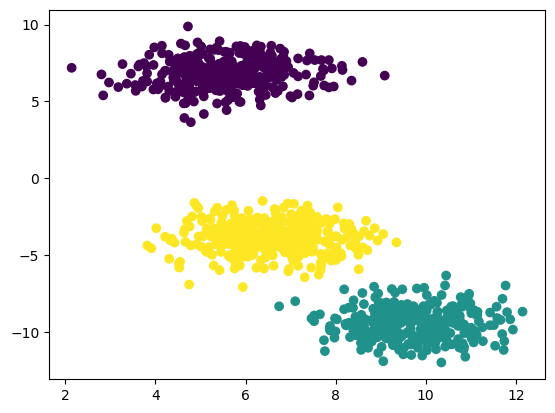

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
### standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [13]:
### Elbow method to selet k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\91995\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\91995\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\91995\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\91995\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [14]:
wcss

[1340.0000000000002,
 443.53545580962884,
 174.14677059061816,
 139.7658228244628,
 101.46873441189786,
 73.04980573250032,
 63.770446681494114,
 54.848956736725796,
 52.53225077688503,
 41.24283577566818]

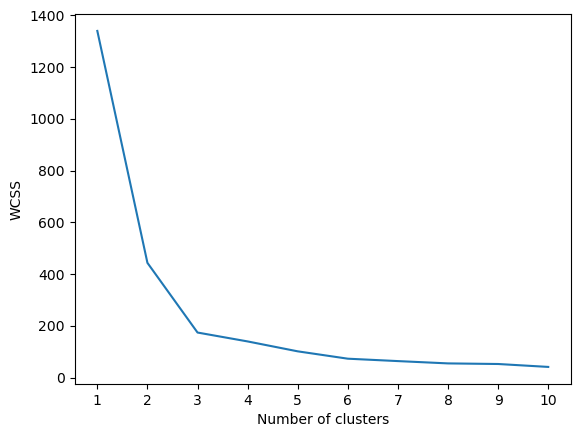

In [15]:
### plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [17]:
kmeans.fit_predict(X_train_scaled)

C:\Users\91995\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([2, 0, 0, 1, 0, 0, 2, 0, 1, 2, 1, 1, 0, 0, 2, 0, 0, 1, 0, 2, 2, 2,
       1, 0, 1, 0, 2, 2, 1, 1, 2, 2, 2, 2, 0, 2, 0, 2, 1, 1, 2, 1, 2, 0,
       2, 0, 1, 0, 2, 0, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1, 0, 2, 1, 0, 0, 2,
       2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 2, 2, 1, 1, 1,
       2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 1, 2, 1, 0, 1, 1, 1, 2, 0, 1,
       2, 1, 2, 2, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2,
       2, 0, 1, 0, 1, 2, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 2,
       2, 0, 2, 2, 1, 1, 1, 1, 2, 2, 1, 0, 1, 0, 1, 1, 1, 1, 2, 0, 2, 1,
       2, 0, 0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 1, 2, 2, 2, 0, 1, 1, 0, 2, 2,
       1, 2, 1, 2, 0, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 2, 1, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 0,
       0, 1, 0, 2, 1, 0, 1, 0, 1, 0, 2, 1, 1, 0, 1, 1, 2, 0, 0, 1, 0, 2,
       2, 0, 0, 1, 1, 1, 2, 1, 0, 0, 2, 0, 1, 1, 0,